In [30]:
import numpy as np
import matplotlib.pyplot as plt

from os.path import join
import sys
sys.path.append(join(".", ".."))
from utils import *


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})


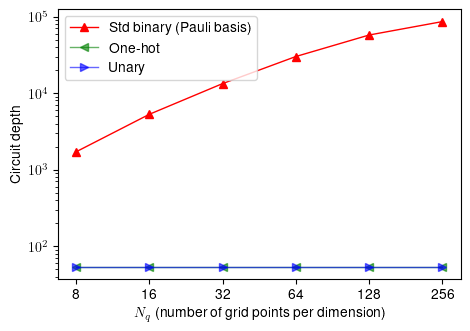

In [41]:

trotter_method = "first_order"
data = np.load(f"../resource_analysis_data/nonlinear/nonlinear_fourier_data.npz")
N_q_vals = data["N_q_vals"]

pauli_basis_circ_depth = data["pauli_basis_circ_depth"]
pauli_basis_two_qubit_gates = data["pauli_basis_two_qubit_gates"]

one_hot_circ_depth = data["one_hot_circ_depth"]
one_hot_two_qubit_gates = data["one_hot_two_qubit_gates"]

unary_circ_depth = data["unary_circ_depth"]
unary_two_qubit_gates = data["unary_two_qubit_gates"]

fig = plt.figure(figsize=(5.2,3.5))

plt.plot(N_q_vals, pauli_basis_circ_depth, '-^', linewidth=1, color="red", label="Std binary (Pauli basis)")
plt.plot(N_q_vals, one_hot_circ_depth, '-<', linewidth=1, color="green", label="One-hot", alpha=0.6)
plt.plot(N_q_vals, unary_circ_depth, '->', linewidth=1, color="blue", label="Unary", alpha=0.6)
plt.ylabel("Circuit depth")
plt.xlabel(rf"$N_q$ (number of grid points per dimension)")
plt.yscale('log')
plt.xscale('log', base=2)
plt.xticks(N_q_vals, [str(j) for j in N_q_vals])
plt.legend(loc="upper left")
plt.savefig(join("..", "..", "figures", "Fig_4B.pdf"), bbox_inches='tight')
plt.show()


In [42]:
print(np.array2string(pauli_basis_circ_depth, formatter={'int_kind': lambda x: f'{x}'}))
print(np.array2string(one_hot_circ_depth, formatter={'int_kind': lambda x: f'{x}'}))
print(np.array2string(unary_circ_depth, formatter={'int_kind': lambda x: f'{x}'}))

[1706 5276 13298 30042 57370 85944]
[54 54 54 54 54 54]
[54 54 54 54 54 54]


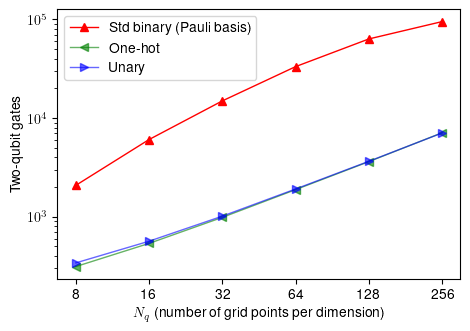

In [43]:

fig = plt.figure(figsize=(5.2,3.5))

plt.plot(N_q_vals, pauli_basis_two_qubit_gates, '-^', linewidth=1, color="red", label="Std binary (Pauli basis)")
plt.plot(N_q_vals, one_hot_two_qubit_gates, '-<', linewidth=1, color="green", label="One-hot", alpha=0.6)
plt.plot(N_q_vals, unary_two_qubit_gates, '->', linewidth=1, color="blue", label="Unary", alpha=0.6)
plt.ylabel("Two-qubit gates")
plt.xlabel(rf"$N_q$ (number of grid points per dimension)")
plt.yscale('log')
plt.xscale('log', base=2)
plt.xticks(N_q_vals, [str(j) for j in N_q_vals])
plt.legend()
plt.savefig(join("..", "..", "figures", "Fig_4C.pdf"), bbox_inches='tight')
plt.show()

In [44]:
print(np.array2string(pauli_basis_two_qubit_gates, formatter={'int_kind': lambda x: f'{x:.2e}'}))
print(np.array2string(one_hot_two_qubit_gates, formatter={'int_kind': lambda x: f'{x:.2e}'}))
print(np.array2string(unary_two_qubit_gates, formatter={'int_kind': lambda x: f'{x:.2e}'}))

[2.08e+03 6.05e+03 1.49e+04 3.32e+04 6.33e+04 9.50e+04]
[3.12e+02 5.36e+02 9.84e+02 1.88e+03 3.62e+03 7.09e+03]
[3.40e+02 5.64e+02 1.01e+03 1.91e+03 3.64e+03 7.06e+03]


In [45]:
n_x = 7
pauli_basis_total_qubits = 2 * np.log2(N_q_vals).astype(int) + 2 * n_x
one_hot_total_qubits = 2 * N_q_vals + 2 * n_x
unary_total_qubits = 2 * (N_q_vals - 1) + 2 * n_x

print(np.array2string(pauli_basis_total_qubits * pauli_basis_circ_depth, formatter={'int_kind': lambda x: f'{x:.2e}'}))
print(np.array2string(one_hot_total_qubits * one_hot_circ_depth, formatter={'int_kind': lambda x: f'{x:.2e}'}))
print(np.array2string(unary_total_qubits * unary_circ_depth, formatter={'int_kind': lambda x: f'{x:.2e}'}))

[3.41e+04 1.16e+05 3.19e+05 7.81e+05 1.61e+06 2.58e+06]
[1.62e+03 2.48e+03 4.21e+03 7.67e+03 1.46e+04 2.84e+04]
[1.51e+03 2.38e+03 4.10e+03 7.56e+03 1.45e+04 2.83e+04]
